In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers,datasets
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from cv2 import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import keras_tuner as kt

In [3]:
#Get data
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

In [4]:
train_images.shape

(50000, 32, 32, 3)

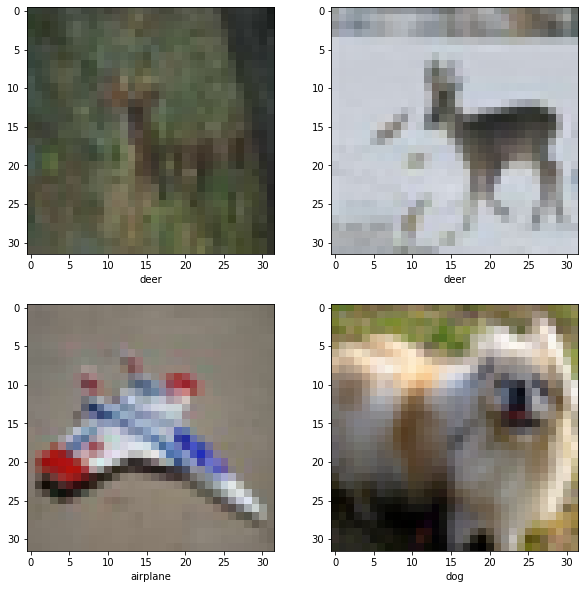

In [27]:
#Define classes
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
#Show example image
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.imshow(train_images[10])
plt.xlabel(class_names[train_labels[10][0]])

plt.subplot(2,2,2)
plt.imshow(train_images[20])
plt.xlabel(class_names[train_labels[20][0]])
           
plt.subplot(2,2,3)
plt.imshow(train_images[30])
plt.xlabel(class_names[train_labels[30][0]])

plt.subplot(2,2,4)
plt.imshow(train_images[40])
plt.xlabel(class_names[train_labels[40][0]])
plt.show()

In [31]:
#Define a model builder function to find hyperparameters
def build_model(hp):
    model=keras.models.Sequential()
    #First convonutional layer
    hp_unit1=hp.Int("hp_unit1",min_value=16,max_value=64,step=4)
    model.add(layers.Conv2D(hp_unit1, (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.MaxPooling2D((2, 2)))
    #Second convonutional layer
    hp_unit2=hp.Int("hp_unit2",min_value=16,max_value=128,step=4)
    model.add(layers.Conv2D(hp_unit2, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    #Third convonutional layer
    hp_unit3=hp.Int("hp_unit3",min_value=16,max_value=128,step=4)
    model.add(layers.Conv2D(hp_unit3, (3, 3), activation='relu'))
    #Convert 3D tensor into 1D output
    model.add(layers.Flatten())
    hp_unit4=hp.Int("hp_unit4",min_value=16,max_value=128,step=4)
    model.add(layers.Dense(hp_unit4, activation='relu'))
    model.add(layers.Dense(10))
    #Compile model
    hp_lr=hp.Choice("learning_rate",values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_lr),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])
    return model

In [35]:
#Instantiate tuner
tuner1=kt.Hyperband(build_model,objective="accuracy", max_epochs=10,factor=3,overwrite=True)
#"overwrite=True" to overwrite tuner from previous project
#Create a callback to stop trainig early
stop_early=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5)

In [36]:
#Find optimal hyperparamters
tuner1.search(train_images,train_labels,epochs=50, validation_split=0.2, callbacks=[stop_early])
best_hps=tuner1.get_best_hyperparameters(num_trials=1)[0]
print(best_hps.get("hp_unit1"))

Trial 30 Complete [00h 11m 06s]
accuracy: 0.10215000063180923

Best accuracy So Far: 0.8416249752044678
Total elapsed time: 01h 37m 55s
INFO:tensorflow:Oracle triggered exit
40


In [45]:
print(best_hps.get("hp_unit1"))
print(best_hps.get("hp_unit2"))
print(best_hps.get("hp_unit3"))
print(best_hps.get("hp_unit4"))
print(best_hps.get("learning_rate"))

40
72
108
96
0.001


In [46]:
#Find the optimal number of epochs
trial_model=tuner1.hypermodel.build(best_hps)
history=trial_model.fit(train_images,train_labels,epochs=50, validation_data=(test_images, test_labels))
#Record the validation accuracy for each epoch
val_acc_per_epoch=history.history["val_accuracy"]
#Find the the epoch at which the validation accuracy is highest
perf_epoch=val_acc_per_epoch.index(max(val_acc_per_epoch)) + 1
print('Best epoch: %d' % (perf_epoch,))

Epoch 1/50
1563/1563 [==============================] - 61s 39ms/step - loss: 1.5208 - accuracy: 0.4472 - val_loss: 1.2844 - val_accuracy: 0.5348
Epoch 2/50
1563/1563 [==============================] - 65s 42ms/step - loss: 1.1612 - accuracy: 0.5889 - val_loss: 1.0900 - val_accuracy: 0.6129
Epoch 3/50
1563/1563 [==============================] - 61s 39ms/step - loss: 1.0040 - accuracy: 0.6487 - val_loss: 1.0262 - val_accuracy: 0.6393
Epoch 4/50
1563/1563 [==============================] - 66s 42ms/step - loss: 0.8923 - accuracy: 0.6863 - val_loss: 0.9462 - val_accuracy: 0.6728
Epoch 5/50
1563/1563 [==============================] - 62s 40ms/step - loss: 0.8133 - accuracy: 0.7152 - val_loss: 0.8722 - val_accuracy: 0.6993
Epoch 6/50
1563/1563 [==============================] - 61s 39ms/step - loss: 0.7439 - accuracy: 0.7385 - val_loss: 0.8774 - val_accuracy: 0.6994
Epoch 7/50
1563/1563 [==============================] - 58s 37ms/step - loss: 0.6878 - accuracy: 0.7598 - val_loss: 0.8841 -

In [6]:
import tensorflow_docs as tfdocs
import tensorflow_docs.modeling
import tensorflow_docs.plots

In [10]:
#Visualize data across 50 epochs
history_dic={}
history_dic["trial_model"]=history
plotter_acc=tfdocs.plots.HistoryPlotter(metric="accuracy")
plt.subplot(1,2,1)
plotter_acc.plot(history_dic)
plt.plot()

plt.subplot(1,2,2)
plotter_loss=tfdocs.plots.HistoryPlotter(metric="loss")
plotter_loss.plot(history_dic)

NameError: name 'history' is not defined

In [5]:
#Implement data augmentation
data_augmentation = keras.Sequential(
  [layers.experimental.preprocessing.RandomFlip("horizontal", input_shape=(32, 32,3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1)])

In [54]:
#Build second trial model with augmentation layer
trial_model2=keras.Sequential()
trial_model2.add(data_augmentation)
trial_model2.add(tuner1.hypermodel.build(best_hps))
trial_model2.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_1 (Sequential)    (None, 32, 32, 3)         0         
_________________________________________________________________
sequential (Sequential)      (None, 10)                264158    
Total params: 264,158
Trainable params: 264,158
Non-trainable params: 0
_________________________________________________________________


In [57]:
#Compile and train the second trial model with augmentation layer for 50 epochs
op_lr=0.001
trial_model2.compile(optimizer=keras.optimizers.Adam(learning_rate=op_lr),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])
history2=trial_model2.fit(train_images,train_labels,epochs=50, validation_data=(test_images, test_labels))

Epoch 1/50
1563/1563 [==============================] - 75s 48ms/step - loss: 1.6141 - accuracy: 0.4090 - val_loss: 1.2773 - val_accuracy: 0.5406
Epoch 2/50
1563/1563 [==============================] - 78s 50ms/step - loss: 1.3193 - accuracy: 0.5291 - val_loss: 1.1694 - val_accuracy: 0.5778
Epoch 3/50
1563/1563 [==============================] - 129s 82ms/step - loss: 1.2120 - accuracy: 0.5710 - val_loss: 1.1656 - val_accuracy: 0.5873
Epoch 4/50
1563/1563 [==============================] - 154s 98ms/step - loss: 1.1496 - accuracy: 0.5921 - val_loss: 1.1332 - val_accuracy: 0.6058
Epoch 5/50
1563/1563 [==============================] - 114s 73ms/step - loss: 1.0978 - accuracy: 0.6146 - val_loss: 1.0609 - val_accuracy: 0.6358
Epoch 6/50
1563/1563 [==============================] - 644s 412ms/step - loss: 1.0551 - accuracy: 0.6284 - val_loss: 0.9975 - val_accuracy: 0.6550
Epoch 7/50
1563/1563 [==============================] - 1920s 1s/step - loss: 1.0263 - accuracy: 0.6403 - val_loss: 1.0

In [1]:
#Visualize improvement
history_dic["trial_model2"]=history2
plt.subplot(1,2,1)
plotter_acc2=tf.docs.plots.HistoryPlotter(metric="accuracy")
plotter_acc2.plot(history_dic["trial_model2"])

plt.subplot(1,2,2)
plotter_loss2=tf.docs.plots.HistoryPlotter(metric="loss")
plotter_loss2.plot(history_dic["trial_model2"])

NameError: name 'history2' is not defined

In [9]:
#Implement a dropout
trial_model3=keras.Sequential()
trial_model3.add(data_augmentation)
trial_model3.add(layers.Conv2D(40, (3, 3), activation='relu', input_shape=(32, 32, 3)))
trial_model3.add(layers.MaxPooling2D((2, 2)))
trial_model3.add(layers.Conv2D(72, (3, 3), activation='relu'))
trial_model3.add(layers.MaxPooling2D((2, 2)))
trial_model3.add(layers.Conv2D(108, (3, 3), activation='relu'))
trial_model3.add(layers.Dropout(0.2))#Dropout with 20% prob.
trial_model3.add(layers.Flatten())
trial_model3.add(layers.Dense(96, activation='relu'))
trial_model3.add(layers.Dense(10))

trial_model3.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=['accuracy'])

In [11]:
history3=trial_model3.fit(train_images,train_labels,epochs=50, validation_data=(test_images, test_labels))

Epoch 1/50
1563/1563 [==============================] - 76s 48ms/step - loss: 1.6422 - accuracy: 0.4009 - val_loss: 1.3219 - val_accuracy: 0.5187
Epoch 2/50
1563/1563 [==============================] - 71s 46ms/step - loss: 1.3533 - accuracy: 0.5132 - val_loss: 1.2138 - val_accuracy: 0.5683
Epoch 3/50
1563/1563 [==============================] - 72s 46ms/step - loss: 1.2499 - accuracy: 0.5556 - val_loss: 1.1402 - val_accuracy: 0.5967
Epoch 4/50
1563/1563 [==============================] - 72s 46ms/step - loss: 1.1710 - accuracy: 0.5846 - val_loss: 1.0898 - val_accuracy: 0.6180
Epoch 5/50
1563/1563 [==============================] - 72s 46ms/step - loss: 1.1289 - accuracy: 0.5996 - val_loss: 1.0047 - val_accuracy: 0.6482
Epoch 6/50
1563/1563 [==============================] - 72s 46ms/step - loss: 1.0882 - accuracy: 0.6172 - val_loss: 1.0291 - val_accuracy: 0.6350
Epoch 7/50
1563/1563 [==============================] - 73s 47ms/step - loss: 1.0557 - accuracy: 0.6288 - val_loss: 0.9240 -

In [21]:
predictions=trial_model3.predict(test_images)

In [22]:
import numpy as np

In [46]:
#Use the model to make predictions
def model_eval(index):
    pred_index=np.argmax(predictions[index])
    pred_label=class_names[pred_index]
    plt.subplot(1,2,1)
    plt.imshow(test_images[index])
    plt.subplot(1,2,2)
    plt.bar(range(10),predictions[index])
    plt.show()
    print("Expected label:{}".format(class_names[test_labels[index][0]]))
    print("Predicted label:{}".format(pred_label))
  

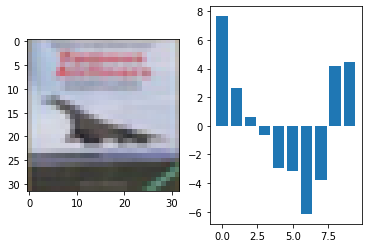

Expected label:airplane
Predicted label:airplane


In [47]:
model_eval(3)

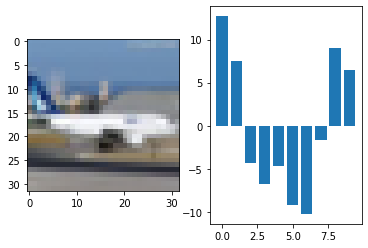

Expected label:airplane
Predicted label:airplane


In [48]:
model_eval(90)

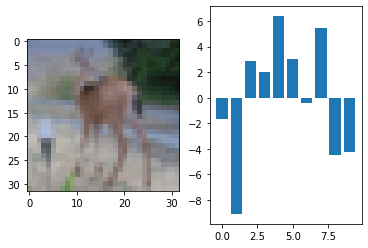

Expected label:deer
Predicted label:deer


In [50]:
model_eval(100)

In [51]:
#Save model
trial_model3.save("cifar10_imageClassifier")

INFO:tensorflow:Assets written to: cifar10_imageClassifier/assets
